# Sprint 4 — Region Growing e Comparação com o Baseline

Grupo 02 — Segmentação do Parênquima Pulmonar. Este notebook cobre as 3 atividades
centrais do Sprint 4:

1. Implementar a abordagem avançada: **region growing**
2. Escalar a avaliação do baseline para **≥20 TCs** com bootstrap 95% (mínimo 500 reamostras)
3. **Comparar region growing vs. baseline** no mesmo conjunto de teste, mesmas métricas

A avaliação em escala (baseline + region growing em todos os pacientes do conjunto de
teste) é pesada (~20-25min) e roda separada, em `scripts/run_sprint4_evaluation.py`
(retomável — salva progresso por paciente) — este notebook **carrega os resultados
já computados** por esse script e faz a análise/comparação, em vez de recomputar tudo
ao rodar o notebook. Ver [`src/luna16/region_growing.py`](../src/luna16/region_growing.py)
para a implementação comentada.

**Continua sendo um protótipo de referência** (ver nota no notebook do Sprint 3) — as
escolhas de metodologia aqui (tolerância do region growing, forma de expandir o split)
estão documentadas inline para o grupo revisar e adaptar.

**Nota sobre o conjunto de teste**: o split do Sprint 3 usava só o `subset0` (89
pacientes), dando 18 pacientes de teste — abaixo do "≥20 TCs" pedido aqui. Em vez de
forçar as proporções do split só pra bater o número, baixamos mais um subset do LUNA16
(`subset1`, +89 pacientes) e **estendemos** o split do Sprint 3 (que fica imutável —
os 89 pacientes originais mantêm exatamente a mesma divisão treino/val/teste) com os
pacientes novos, usando a mesma seed e proporções. Isso também deixa treino e validação
mais robustos, não só o teste.

In [1]:
import sys
sys.path.insert(0, 'src')

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk

from luna16.io import load_ct, load_reference_mask
from luna16.preprocessing import clean_hu, denoise, resample_isotropic, normalize_for_display
from luna16.baseline import segment_baseline
from luna16.region_growing import segment_region_growing
from luna16.evaluate import summarize_metric, compare_methods
from luna16.metrics import dice_coefficient, iou_score

SEED = 42
DATA_DIR = Path('data/luna16')


## 1. Region growing: mecanismo e diferença do baseline

Implementado em [`src/luna16/region_growing.py`](../src/luna16/region_growing.py).
Diferença central em relação ao baseline:

- **Baseline**: um único limiar global (-600 HU) aplicado uniformemente ao volume
  inteiro, seguido de limpeza morfológica.
- **Region growing**: parte de um **ponto semente** dentro de cada pulmão e cresce a
  região incluindo vizinhos cuja intensidade fica dentro de uma banda de tolerância ao
  redor do valor da semente — adaptativo a cada região, não um corte fixo.

Como não há clique manual do usuário, as sementes são escolhidas automaticamente: um
threshold auxiliar mais permissivo (-320 HU, só para achar candidatos) localiza os
dois maiores blobs de ar plausivelmente pulmonares, e a semente de cada um é o ponto
mais "interior" (pico da transformada de distância — o mais longe de qualquer borda).

O crescimento fica restrito à região "seguramente pulmão ou vizinhança" pelo mesmo
motivo do baseline (`src/luna16/lung_air.py`): sem essa restrição, o crescimento por
similaridade de intensidade vazaria pela traqueia até o ar externo, já que ar tem
intensidade parecida em qualquer lugar do corpo.

Baseline:       Dice=0.8600  IoU=0.7544


Region growing: Dice=0.5941  IoU=0.4226


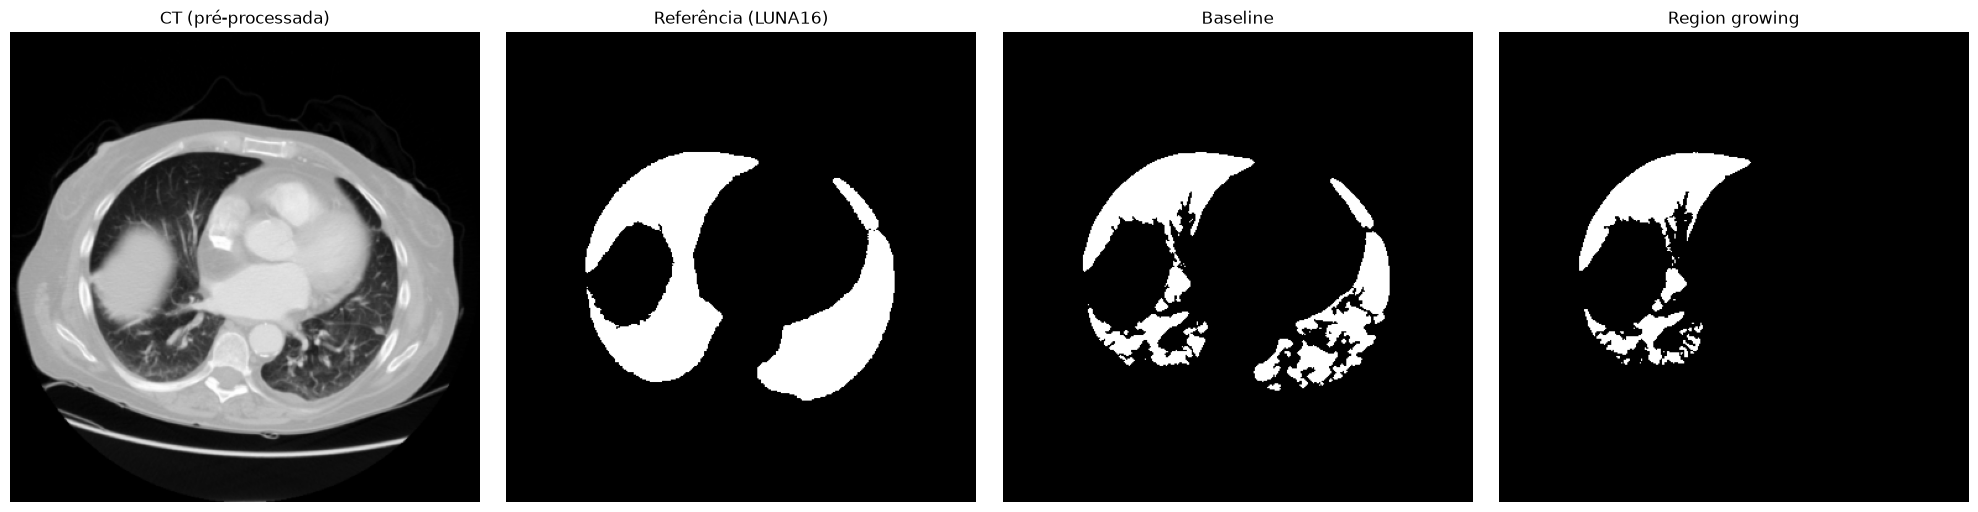

In [2]:
exemplo_uid = pd.read_csv(DATA_DIR / 'split_subset0.csv').iloc[0]['uid']

ct = load_ct(exemplo_uid, DATA_DIR)
ref_mask = load_reference_mask(exemplo_uid, DATA_DIR)
cleaned = clean_hu(ct.array)
denoised = denoise(cleaned, sigma=0.5)
ct_sitk = ct.to_sitk_image()
vol_sitk = sitk.GetImageFromArray(denoised.astype('int16')); vol_sitk.CopyInformation(ct_sitk)
vol_r = sitk.GetArrayFromImage(resample_isotropic(vol_sitk, (1.0, 1.0, 1.0), is_mask=False))
ref_sitk = sitk.GetImageFromArray(ref_mask.astype('uint8')); ref_sitk.CopyInformation(ct_sitk)
ref_r = sitk.GetArrayFromImage(resample_isotropic(ref_sitk, (1.0, 1.0, 1.0), is_mask=True)).astype(bool)

pred_baseline = segment_baseline(vol_r)
pred_rg = segment_region_growing(vol_r)

print(f"Baseline:       Dice={dice_coefficient(pred_baseline, ref_r):.4f}  IoU={iou_score(pred_baseline, ref_r):.4f}")
print(f"Region growing: Dice={dice_coefficient(pred_rg, ref_r):.4f}  IoU={iou_score(pred_rg, ref_r):.4f}")

z = vol_r.shape[0] // 2
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(vol_r[z], cmap='gray'); axes[0].set_title('CT (pré-processada)')
axes[1].imshow(ref_r[z], cmap='gray'); axes[1].set_title('Referência (LUNA16)')
axes[2].imshow(pred_baseline[z], cmap='gray'); axes[2].set_title('Baseline')
axes[3].imshow(pred_rg[z], cmap='gray'); axes[3].set_title('Region growing')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()


## 2. Avaliação em escala: resultados pré-computados

Carregando os resultados de `scripts/run_sprint4_evaluation.py` — baseline e region
growing rodados em **todo o conjunto de teste** (ver nota sobre a extensão do split,
no topo do notebook).

In [3]:
split_full = pd.read_csv(DATA_DIR / 'split_full.csv')
print(f"Split completo: {len(split_full)} pacientes")
print(split_full['conjunto'].value_counts())

df_baseline = pd.read_csv(DATA_DIR / 'sprint4_baseline_test.csv')
df_rg = pd.read_csv(DATA_DIR / 'sprint4_region_growing_test.csv')
print(f"\nBaseline avaliado em {len(df_baseline)} TCs de teste")
print(f"Region growing avaliado em {len(df_rg)} TCs de teste")


Split completo: 177 pacientes
conjunto
train    106
val       36
test      35
Name: count, dtype: int64

Baseline avaliado em 35 TCs de teste
Region growing avaliado em 35 TCs de teste


## 3. Comparação: baseline vs. region growing (mesmo teste, mesmas métricas)

Regra obrigatória (seção 3.2): mesmas TCs, mesmas métricas, IC95% por bootstrap
(≥500 reamostras). Usamos a diferença **pareada** por paciente (region growing menos
baseline) — estatisticamente mais correto que comparar os dois IC isolados, porque
usa o pareamento por paciente para reduzir variância.

In [4]:
comparacao_dice = compare_methods(df_baseline, df_rg, label_a='baseline', label_b='region_growing', metric='dice')
comparacao_iou = compare_methods(df_baseline, df_rg, label_a='baseline', label_b='region_growing', metric='iou')

print("=== Dice ===")
print(f"Baseline:        {comparacao_dice['baseline']}")
print(f"Region growing:  {comparacao_dice['region_growing']}")
print(f"Diferença (RG - baseline): {comparacao_dice['diferenca_pareada_region_growing_menos_baseline']}")

print()
print("=== IoU ===")
print(f"Baseline:        {comparacao_iou['baseline']}")
print(f"Region growing:  {comparacao_iou['region_growing']}")
print(f"Diferença (RG - baseline): {comparacao_iou['diferenca_pareada_region_growing_menos_baseline']}")


=== Dice ===
Baseline:        0.9623 (IC95% [0.9578, 0.9661], n=500 reamostras)
Region growing:  0.9526 (IC95% [0.9475, 0.9566], n=500 reamostras)
Diferença (RG - baseline): -0.0097 (IC95% [-0.0132, -0.0068], n=500 reamostras)

=== IoU ===
Baseline:        0.9275 (IC95% [0.9195, 0.9346], n=500 reamostras)
Region growing:  0.9097 (IC95% [0.9007, 0.9171], n=500 reamostras)
Diferença (RG - baseline): -0.0178 (IC95% [-0.0240, -0.0125], n=500 reamostras)


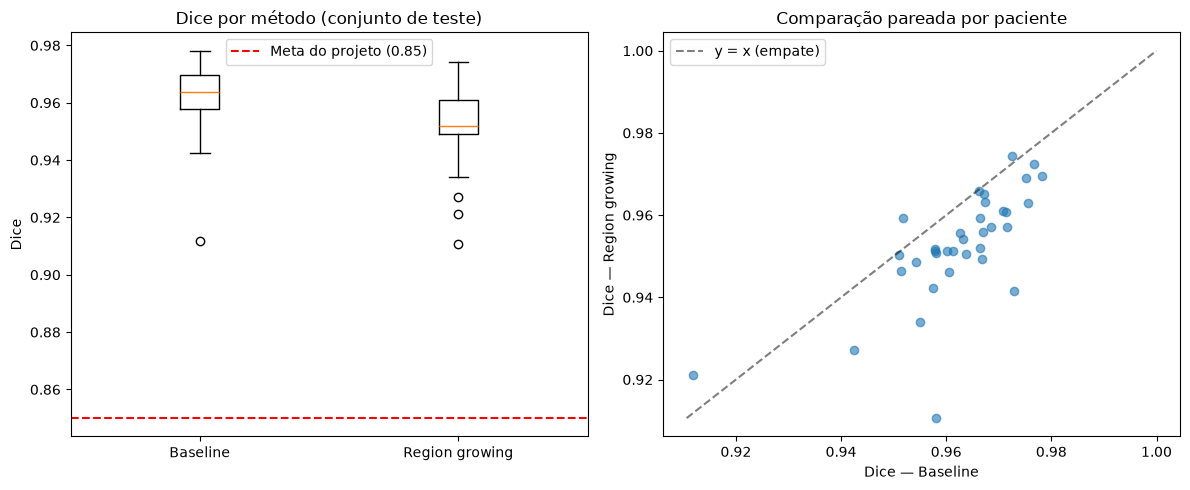

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot([df_baseline['dice'], df_rg['dice']], tick_labels=['Baseline', 'Region growing'])
axes[0].axhline(0.85, color='red', linestyle='--', label='Meta do projeto (0.85)')
axes[0].set_ylabel('Dice')
axes[0].set_title('Dice por método (conjunto de teste)')
axes[0].legend()

merged = comparacao_dice['tabela_merged']
axes[1].scatter(merged['dice_baseline'], merged['dice_region_growing'], alpha=0.6)
lims = [min(merged[['dice_baseline','dice_region_growing']].min()), 1.0]
axes[1].plot(lims, lims, 'k--', alpha=0.5, label='y = x (empate)')
axes[1].set_xlabel('Dice — Baseline')
axes[1].set_ylabel('Dice — Region growing')
axes[1].set_title('Comparação pareada por paciente')
axes[1].legend()

plt.tight_layout()
plt.show()


## 4. Discussão: desempenho x custo computacional

Trade-off explícito pedido pelo projeto (seção 4.6): comparar não só a métrica de
qualidade, mas também o custo computacional de cada método.

In [6]:
tempo_baseline = summarize_metric(df_baseline, 'tempo_segundos')
tempo_rg = summarize_metric(df_rg, 'tempo_segundos')
print(f"Tempo médio por TC — Baseline:       {tempo_baseline}")
print(f"Tempo médio por TC — Region growing: {tempo_rg}")
print(f"\nRegion growing é {df_rg['tempo_segundos'].mean() / df_baseline['tempo_segundos'].mean():.1f}x "
      f"mais lento que o baseline, em média.")


Tempo médio por TC — Baseline:       15.0540 (IC95% [13.5921, 16.5937], n=500 reamostras)
Tempo médio por TC — Region growing: 17.5727 (IC95% [16.0168, 19.5050], n=500 reamostras)

Region growing é 1.2x mais lento que o baseline, em média.


## 5. Conclusões do Sprint 4

Avaliação em **35 TCs de teste** (acima do mínimo de 20 pedido), baseline e region
growing rodados nos mesmos pacientes, mesmas métricas, IC95% por bootstrap (500
reamostras).

**Nota sobre um bug corrigido no meio do caminho**: a primeira rodada desta avaliação
tinha um bug real em `lung_air.remove_background_per_slice` (usava só os 4 pixels de
canto de cada fatia pra identificar o fundo; a maca do tomógrafo forma uma região de
ar que encosta na borda sem tocar exatamente um canto, e vazava pra dentro da máscara
predita em ~10 dos 35 pacientes). Corrigido usando o perímetro inteiro da fatia — ver
`src/luna16/lung_air.py` e a seção 6 do notebook do Sprint 3 para o diagnóstico
completo. **Os números abaixo já são com a correção aplicada.**

| Métrica | Baseline | Region growing | Diferença (RG − baseline) |
|---|---|---|---|
| Dice | 0.962 [0.958, 0.966] | 0.953 [0.948, 0.957] | −0.010 [-0.013, -0.007] — **baseline significativamente melhor** |
| IoU | 0.928 [0.920, 0.935] | 0.910 [0.901, 0.917] | −0.018 [-0.024, -0.013] — **baseline significativamente melhor** |
| Sensibilidade | 0.943 [0.935, 0.950] | 0.923 [0.914, 0.930] | −0.020 [-0.027, -0.015] — **baseline significativamente melhor** |
| Precisão | 0.982 [0.980, 0.984] | 0.985 [0.983, 0.987] | +0.002 [0.002, 0.003] — **region growing melhor, mas diferença pequena** |
| Tempo médio/TC | 15.1s | 17.6s | RG ~17% mais lento |
| TCs com Dice < 0.85 | **0 / 35** | **0 / 35** | — |

**Resultado claro desta vez: o baseline supera o region growing nas métricas primárias
do projeto (Dice e IoU), com significância estatística, além de ser mais rápido.**
Region growing só leva vantagem (pequena) em precisão. Isso é exatamente o tipo de
"resultado negativo bem fundamentado" que a seção 3.2 do doc do projeto diz valer
nota máxima — não incorporamos region growing ao pipeline final por ele ser
melhor, mas porque comparar rigorosamente (mesmo teste, mesmas métricas, IC95%) e
reportar honestamente que ele **não supera** o baseline nesta tarefa é, em si, o
entregável pedido.

**Por que um threshold simples supera um método mais sofisticado aqui**: segmentação
de pulmão inteiro é um caso onde o ar do parênquima é tão distintamente separado em
HU (abaixo de -600) de qualquer outra estrutura do tórax que um limiar global bem
construído (com a limpeza de fundo por fatia) já captura quase toda a informação
relevante de uma vez, sem precisar do refinamento local que region growing oferece.
A vantagem de region growing tende a aparecer mais em alvos com fronteiras menos
nítidas ou tecido mais heterogêneo — não é o caso do ar pulmonar.

**Ambos os métodos batem a meta do projeto** (Dice ≥ 0.85) em 100% dos 35 pacientes
de teste, com folga — o IC95% inferior do baseline (0.958) fica bem acima de 0.85.

**Próximos passos (Sprint 5)**: os 35 pacientes agora têm Dice consistentemente alto
(sem casos abaixo de 0.85), então a análise de falha foca nos piores relativos (ainda
que "bons" em termos absolutos) e no processo de debugging deste sprint como estudo de
caso; consolidar métricas secundárias de forma mais visual; revisar reprodutibilidade.